## Vegetation Monitoring with HLS Data on the Planetary Computer

![NDVI anomalies during growing season](./images/ndvi-anomalies.png)

Monitoring vegetation over time is critical for understanding land health, agricultural productivity, and environmental change. This notebook uses Harmonized Landsat and Sentinel-2 (HLS) data to analyze vegetation patterns and detect unexpected changes across a selected agricultural region.

### Objective
**This tutorial demonstrates how to detect vegetation anomalies in agricultural areas using satellite imagery.** You'll learn to identify pixels where crops experienced unexpected declines in vegetation health compared to regional trends, which could indicate issues like pest damage, disease, drought stress, or other disturbances.

**What you'll build:** An automated system that processes multi-temporal satellite data to flag locations and dates where vegetation health deviated significantly from expected patterns.

### Analysis Workflow
This notebook will guide you through these key steps:

1. **📍 Define Study Area** - Provide a set of field boundaries or query the USDA Crop Sequence Boundaries dataset
2. **🛰️ Access Satellite Data** - Query and load Harmonized Landsat-Sentinel (HLS) imagery from Microsoft's Planetary Computer
3. **☁️ Filter Cloud Contamination** - Apply quality masks to exclude cloudy observations and retain only clear imagery
4. **🌾 Identify Cropland** - Use land cover data to focus analysis on agricultural pixels
5. **📊 Calculate NDVI** - Compute the Normalized Difference Vegetation Index as a measure of vegetation health
6. **📈 Establish Baseline Trends** - Generate expected vegetation patterns by averaging across all cropland pixels
7. **🚨 Detect Anomalies** - Identify locations where individual pixels deviate significantly from expected trends
8. **🗓️ Map Timing** - Determine when anomalous events first occurred at each location
9. **📤 Export Results** - Generate outputs suitable for further analysis or dashboard integration

### Expected Outcomes
By the end of this analysis, you'll have:
- Interactive maps showing where and when vegetation anomalies occurred
- Time-series visualizations of vegetation change throughout the growing season
- Tabular data exports containing anomaly locations and dates
- A reusable workflow that can be applied to any geographic region

➡️ **Next notebook in this series:**  
- [Monitoring for Extreme Weather Events](/tutorials/climate-risk.ipynb) (Advanced)

⬅️ **Previous notebook in this series:**
- [Site Monitoring Foundations](/tutorials/site-monitoring-foundatons.ipynb) (Beginner)


Conda environment.yml for this notebook

```yml
name: geo_py312
channels:
  - conda-forge
  - defaults
dependencies:
  - python=3.12
  - duckdb
  - gdal=3.10
  - pip
  - dask
  - flox
  - folium
  - geopandas
  - imageio
  - ipykernel
  - jupyter
  - jupyterlab
  - matplotlib
  - nbformat
  - numpy
  - obstore
  - pandas
  - planetary-computer
  - pyproj
  - pystac
  - pystac-client
  - rasterio
  - rioxarray
  - rtree
  - shapely
  - xarray
  - zarr
  - pip:
      - odc-stac>=0.4
```

In [15]:
import io
from datetime import datetime

import branca.colormap as cm
import duckdb
import folium
import geopandas as gpd
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np
import odc.stac
import pyproj
import pystac
import pystac_client
import planetary_computer
import rioxarray  # noqa
import xarray as xr
from IPython.display import Image
from rasterio.features import rasterize, shapes
from shapely.geometry import box, shape
from shapely.ops import transform
from tqdm import trange

### Define an area of interest

This example shows how to query a `geoparquet` copy of the [USDA Crop Sequence Boundaries dataset](https://source.coop/repositories/fiboa/us-usda-cropland/description) for a given bounding box. You can also provide your own set of field boundaries here:

In [16]:
target_crs = "EPSG:5070"

features = {
    "type": "FeatureCollection",
    "features": [
        {
            "type": "Feature",
            "properties": {},
            "geometry": {
                "coordinates": [
                    [
                        [-88.92564739516503, 41.80448140623932],
                        [-88.92564739516503, 41.79687814101885],
                        [-88.91508713682285, 41.79687814101885],
                        [-88.91508713682285, 41.80448140623932],
                        [-88.92564739516503, 41.80448140623932],
                    ]
                ],
                "type": "Polygon",
            },
        },
        {
            "type": "Feature",
            "properties": {},
            "geometry": {
                "coordinates": [
                    [
                        [-88.92570673529887, 41.789629439783965],
                        [-88.92570673529887, 41.7826901402419],
                        [-88.91526559593807, 41.7826901402419],
                        [-88.91526559593807, 41.789629439783965],
                        [-88.92570673529887, 41.789629439783965],
                    ]
                ],
                "type": "Polygon",
            },
        },
        {
            "type": "Feature",
            "properties": {},
            "geometry": {
                "coordinates": [
                    [
                        [-88.94109457426785, 41.8190678637379],
                        [-88.94109457426785, 41.81190687629453],
                        [-88.93304280716336, 41.81190687629453],
                        [-88.93304280716336, 41.8190678637379],
                        [-88.94109457426785, 41.8190678637379],
                    ]
                ],
                "type": "Polygon",
            },
        },
        {
            "type": "Feature",
            "properties": {},
            "geometry": {
                "coordinates": [
                    [
                        [-88.90564252412616, 41.81955530327289],
                        [-88.89563604896044, 41.81955530327289],
                        [-88.89563604896044, 41.82670574947619],
                        [-88.90564252412616, 41.82670574947619],
                        [-88.90564252412616, 41.81955530327289],
                    ]
                ],
                "type": "Polygon",
            },
        },
    ],
}

if features:
    field_gdf = gpd.GeoDataFrame.from_features(features, crs="epsg:4326")
    explore_column = None
else:
    fiboa_url = (
        "https://data.source.coop/fiboa/us-usda-cropland/us_usda_cropland.parquet"
    )
    xmin, ymin, xmax, ymax = -89.15, 41.5, -88.75, 41.65

    field_table = duckdb.sql(
        f"""
      INSTALL spatial;
      LOAD spatial;
      CALL register_geoarrow_extensions();

      select
        id,
        "crop:name",
        determination_datetime,
        ST_Transform(geometry, '{target_crs}', 'EPSG:4326', always_xy := true) as geometry
      from read_parquet('{fiboa_url}')
      where
        ST_Intersects(
          geometry,
          ST_Transform(
            ST_MakeEnvelope({xmin}, {ymin}, {xmax}, {ymax}),
            'EPSG:4326',
            '{target_crs}',
            always_xy := true
          )
        )
      """
    ).arrow()

    field_gdf = gpd.GeoDataFrame.from_arrow(field_table).set_crs(4326)
    explore_column = "crop:name"

In [17]:
field_gdf.explore(explore_column)

### Search for Harmonized Landsat Sentinel-2 data using the Planetary Computer STAC API

The Planetary Computer maintains a copy of the [Harmonized Landsat Sentinel-2 dataset](https://planetarycomputer.microsoft.com/dataset/group/hls2) and has made it available in via the STAC API.

In [18]:
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

The STAC asset keys for the HLS collections are the band labels (e.g. B02) from the respective instrument. To combine the data from both collections, you must use a common name to ensure that the correct bands from each collection are mapped to one another.

> Warning: The common names for the near-infrared bands in the two collections are not coded correctly. You can fix this by setting the common name for Landsat's B05 and Sentinel-2's B8A to 'nir08'.

In [19]:
HLS2_L30 = "hls2-l30"
HLS2_S30 = "hls2-s30"

collections = {
    collection_id: catalog.get_collection(collection_id)
    for collection_id in [
        HLS2_L30,
        HLS2_S30,
    ]
}

for collection_id, collection in collections.items():
    for key, asset in collection.extra_fields["item_assets"].items():
        if collection_id == HLS2_L30 and key == "B05":
            asset["eo:bands"][0]["common_name"] = "nir08"
        if collection_id == HLS2_S30 and key == "B8A":
            asset["eo:bands"][0]["common_name"] = "nir08"

We will use `pystac-client` to search the Planetary Computer catalog for STAC items from the HLS collections for the 2024 growing season (May-October).

To generate an expectation for NDVI trends in local crop fields, we will analyze satellite imagery for an area beyond the exact extent of the provided field boundaries.

In [20]:
buffer_distance_m = 25_000

buffer_bbox = tuple(
    float(coord)
    for coord in (
        field_gdf.geometry.to_crs(target_crs)
        .buffer(buffer_distance_m)
        .to_crs(4326)
        .total_bounds
    )
)

In [21]:
datetime_range = [datetime(2024, 4, 1), datetime(2024, 11, 1)]


search = catalog.search(
    collections=[HLS2_L30, HLS2_S30],
    datetime=datetime_range,
    bbox=buffer_bbox,
)

hls_items = search.item_collection()
print(len(hls_items))

98


The STAC search returns all items intersecting the provided bounding box and matching the other search criteria.

In [22]:
xmin, ymin, xmax, ymax = buffer_bbox
lon, lat = xmin + (xmax - xmin) / 2, ymin + (ymax - ymin) / 2


m = folium.Map([lat, lon], zoom_start=8)

folium.features.GeoJson(
    data=hls_items.to_dict(),
    name="HLS STAC items",
    style_function=lambda feature: {
        "fillColor": "#ffffff",
        "color": "black",
        "weight": 2,
        "dashArray": "5, 5",
    },
).add_to(m)

folium.features.GeoJson(
    data=box(*buffer_bbox),
    name="study area",
    style_function=lambda feature: {
        "fillColor": "#ffffff",
        "color": "orange",
        "weight": 2,
    },
).add_to(m)

folium.features.GeoJson(
    data=features,
    name="field boundaries",
).add_to(m)

folium.LayerControl(collapsed=False).add_to(m)

m

### odc-stac
[odc-stac](https://github.com/opendatacube/odc-stac) is a tool for creating an xarray datacube from a STAC ItemCollection. This is a handy tool because (if the STAC metadata is well structured) you don't have to think about file paths or projections among other details. `odc-stac` will create a lazily-evaluated datacube that represents a mosaic of STAC items. When you call the `.compute()` method on an `xarray` object, it will read actual bytes from the assets.

You can provide some configuration details for a datacube in the form of a dictionary like this:

In [23]:
nodata = -9999

hls_odc_stac_config = {
    collection_id: {
        "assets": {
            "*": {
                "nodata": nodata,
                "data_type": "int16",
            },
            "Fmask": {
                "nodata": 0,
                "data_type": "uint8",
            },
        },
        "aliases": {
            asset["eo:bands"][0]["common_name"]: key
            for key, asset in collection.extra_fields["item_assets"].items()
            if asset["eo:bands"][0].get("common_name")
        },
    }
    for collection_id, collection in collections.items()
}

By default, STAC items from the same day will be combined into a single time coordinate in your datacube. Since we want to consider observations from Landsat and Sentinel-2 as separate observations even if they were collected on the same day, we can provide a function that will return the grouping key for odc-stac. 

In [24]:
def group_by_sensor_and_date(
    item: pystac.Item,
    parsed: odc.stac.ParsedItem,
    idx: int,
) -> str:
    id_split = item.id.split(".")
    sensor = id_split[1]
    day = id_split[3][:7]

    return f"{sensor}_{day}"

You can pass the STAC ItemCollection straight to odc.stac.load, but if you want to limit your analysis to a particular area of interest, you can provide a bounding box in the form of the `x` and `y` coordinate tuples. This is particularly useful because often your area of interest will not cover the entirety of the STAC item footprint, and therefore, you can selectively read chunks of the assets. You can also specify the output CRS and resolution for the array.

`odc.stac.load` will create a 4-dimensional data cube: band (variables in the Dataset), time, x, and y.

In [25]:
# load the xarray Dataset in a CONUS-wide projected CRS
transformer = pyproj.Transformer.from_crs(
    crs_from=4326,
    crs_to=target_crs,
    always_xy=True,
)

aoi = box(*buffer_bbox)
aoi_proj = transform(transformer.transform, aoi)

In [26]:
bbox_proj = aoi_proj.bounds

# these are the ones that we are going to use
bands = ["red", "green", "blue", "nir08", "Fmask"]

stack = odc.stac.load(
    hls_items,
    stac_cfg=hls_odc_stac_config,
    bands=bands,
    crs=target_crs,
    resolution=30,
    chunks={},
    groupby=group_by_sensor_and_date,
    x=(bbox_proj[0], bbox_proj[2]),
    y=(bbox_proj[1], bbox_proj[3]),
).sortby("time")

stack

<xarray.Dataset> Size: 3GB
Dimensions:      (y: 1960, x: 1925, time: 98)
Coordinates:
  * y            (y) float64 16kB 2.14e+06 2.14e+06 ... 2.082e+06 2.081e+06
  * x            (x) float64 15kB 5.549e+05 5.549e+05 ... 6.126e+05 6.126e+05
    spatial_ref  int32 4B 5070
  * time         (time) datetime64[ns] 784B 2024-04-02T17:01:54.392140 ... 20...
Data variables:
    red          (time, y, x) int16 740MB dask.array<chunksize=(1, 1960, 1925), meta=np.ndarray>
    green        (time, y, x) int16 740MB dask.array<chunksize=(1, 1960, 1925), meta=np.ndarray>
    blue         (time, y, x) int16 740MB dask.array<chunksize=(1, 1960, 1925), meta=np.ndarray>
    nir08        (time, y, x) int16 740MB dask.array<chunksize=(1, 1960, 1925), meta=np.ndarray>
    Fmask        (time, y, x) uint8 370MB dask.array<chunksize=(1, 1960, 1925), meta=np.ndarray>

To limit the scope of our analysis to the boundary of DeKalb County (not just its bounding box), we can create an array representation of the boundary using `rasterio.features.rasterize`.

In [27]:
# geographic mask for the original AOI
aoi_mask = rasterize(
    [(aoi_proj, 1)],
    out_shape=(stack.rio.height, stack.rio.width),
    transform=stack.rio.transform(),
    fill=0,
    all_touched=True,
    dtype=np.uint8,
).astype(bool)

The rest of the notebook will involve many datacubes. The easiest way to describe those datacubes is by rendering time series GIFs, so here are some functions to render GIFs in the notebook.

In [51]:
# Function to plot a single frame and return as a BytesIO object
def plot_frame(data, time_idx, title, figsize=(10, 10), units_label=None, **kwargs):
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(data.isel(time=time_idx), **kwargs)
    ax.axis("off")

    # Adjust layout to reduce whitespace
    plt.subplots_adjust(left=0.1, right=0.9, top=0.85, bottom=0.25)

    # Main title at the top
    fig.suptitle(title, fontsize=12, y=0.92)

    # Datetime under the title
    fig.text(
        0.5,
        0.87,
        str(data.time.values[time_idx]).split("T")[0],
        ha="center",
        fontsize=10,
    )

    # Horizontal colorbar below the image
    if kwargs.get("cmap"):
        cbar_ax = fig.add_axes([0.15, 0.15, 0.7, 0.03])
        cbar = plt.colorbar(im, cax=cbar_ax, orientation="horizontal")
        cbar.set_label(units_label, fontsize=10, labelpad=3)
        cbar.ax.xaxis.set_label_position("top")

    buf = io.BytesIO()
    plt.savefig(buf, format="png", bbox_inches="tight", pad_inches=0.1)
    plt.close(fig)
    buf.seek(0)
    return buf


def render_frame(*args, **kwargs):
    plt.figure(figsize=kwargs.get("figsize"))
    img = plot_frame(*args, **kwargs)
    plt.imshow(imageio.imread(img))
    plt.axis("off")
    plt.show()


def render_gif(
    data: xr.DataArray,
    title: str,
    fps: int = 4,
    units_label: str | None = None,
    figsize=(10, 10),
    **kwargs,
):
    # Create frames in memory
    frames = []
    for t in trange(data.sizes["time"]):
        frame = plot_frame(
            data, t, title, figsize=figsize, units_label=units_label, **kwargs
        )
        frames.append(imageio.imread(frame))

    gif_bytes = io.BytesIO()
    imageio.mimsave(gif_bytes, frames, format="GIF", fps=fps, loop=0)
    gif_bytes.seek(0)

    return Image(data=gif_bytes.read())

Here is a view of the images collected during July:

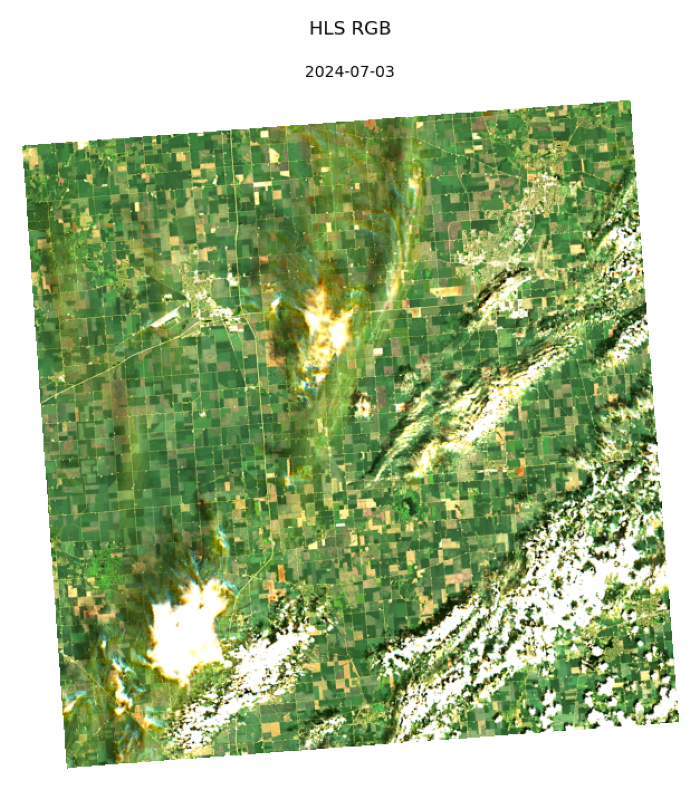

In [53]:
# massage the xarray.Dataset into an RGB array that is ready to plot (scaled 0-1)
rgb_max = 1000

rgb_stack = (
    (
        stack.to_dataarray(dim="band")
        .sel(band=["red", "green", "blue"])
        .where(aoi_mask)
        .where(stack["red"] != nodata)
        .transpose("y", "x", "band", "time")
    )
    / rgb_max
).clip(0, 1)

render_frame(
    rgb_stack,
    title="HLS RGB",
    time_idx=31,
    vmin=0,
    vmax=1000,
    figsize=(10, 10),
)
# render_gif(
#     rgb_stack,
#     "HLS: July 2024",
#     vmin=0,
#     vmax=1000,
#     figsize=(10, 10),
# )

There are a lot of clouds! That could be a problem for our site-monitoring application, but since we have such a rich time series from the combined Landsat and Sentinel-2 dataset, we can still work with it as long as we know how to mask out the clouds and cloud shadows.

The Fmask band contains the information we need to identify pixels we want to exclude from downstream analysis. We need the integer representation for values where any of bits 1, 2, and 3 are `1`.

In [54]:
hls_mask_bitfields = [1, 2, 3]  # cloud shadow, adjacent to cloud shadow, cloud
hls_bitmask = 0
for field in hls_mask_bitfields:
    hls_bitmask |= 1 << field

print(hls_bitmask)

14


We can use the bitwise `&` operator to compare the Fmask array to the integer value to mark pixels that meet are either clouds, cloud shadows, or adjacent to cloud shadows. Green pixels in the GIF represent "clean" values.

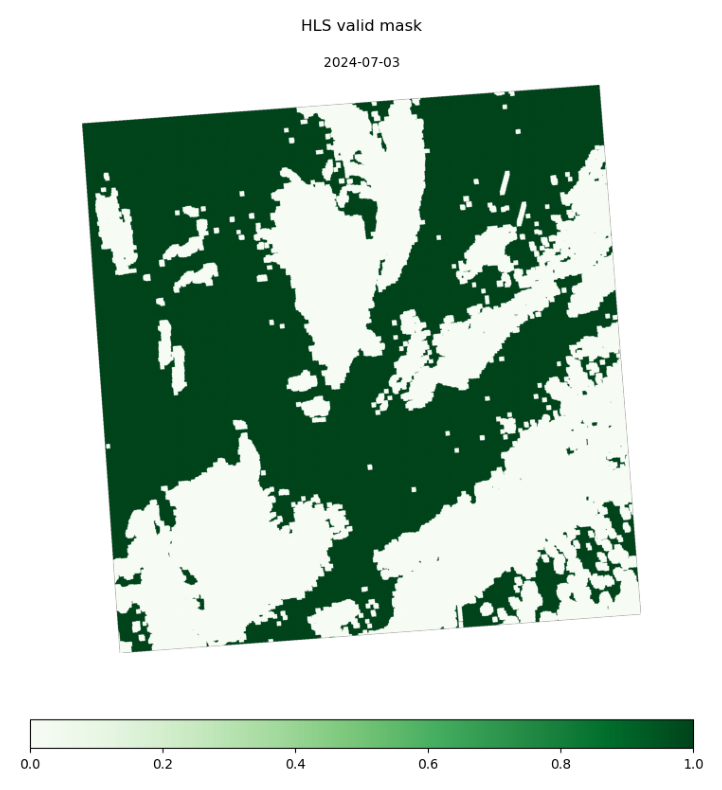

In [55]:
fmask = stack["Fmask"].astype("uint16")
valid_mask = ((fmask & hls_bitmask) == 0).where(aoi_mask).where(stack["red"] != nodata)

render_frame(
    valid_mask,
    title="HLS valid mask",
    time_idx=31,
    vmin=0,
    vmax=1,
    cmap="Greens",
    figsize=(10, 10),
)

# render_gif(
#     valid_mask.sel(time=slice("2024-07-01", "2024-07-31")),
#     "HLS valid mask: July 2024",
#     vmin=0,
#     vmax=1,
#     cmap="Greens",
# )

We can use the valid pixel mask to identify dates when the images are at least 50% valid for our area of interest and exclude those that are not.

In [57]:
valid_proportions = valid_mask.mean(dim=["x", "y"], skipna=True)

valid_threshold = 0.5
valid_datetimes = valid_proportions >= valid_threshold

`cloud_free_stack` is a filtered version of the full imagery stack, where mostly cloudy images have been excluded and invalid pixels masked out. We are calling the `compute()` method to load the data into memory since we will use it for several subsequent plotting and analytical operations, but you could skip it for applications where you want to prioritize memory efficiency.

In [58]:
cloud_free_stack = stack.where(valid_mask == 1).sel(time=valid_datetimes).compute()

cloud_free_stack

<xarray.Dataset> Size: 4GB
Dimensions:      (time: 55, y: 1960, x: 1925)
Coordinates:
  * y            (y) float64 16kB 2.14e+06 2.14e+06 ... 2.082e+06 2.081e+06
  * x            (x) float64 15kB 5.549e+05 5.549e+05 ... 6.126e+05 6.126e+05
    spatial_ref  int32 4B 5070
  * time         (time) datetime64[ns] 440B 2024-04-12T17:01:56.375150 ... 20...
Data variables:
    red          (time, y, x) float32 830MB nan nan nan nan ... nan nan nan nan
    green        (time, y, x) float32 830MB nan nan nan nan ... nan nan nan nan
    blue         (time, y, x) float32 830MB nan nan nan nan ... nan nan nan nan
    nir08        (time, y, x) float32 830MB nan nan nan nan ... nan nan nan nan
    Fmask        (time, y, x) float32 830MB nan nan nan nan ... nan nan nan nan

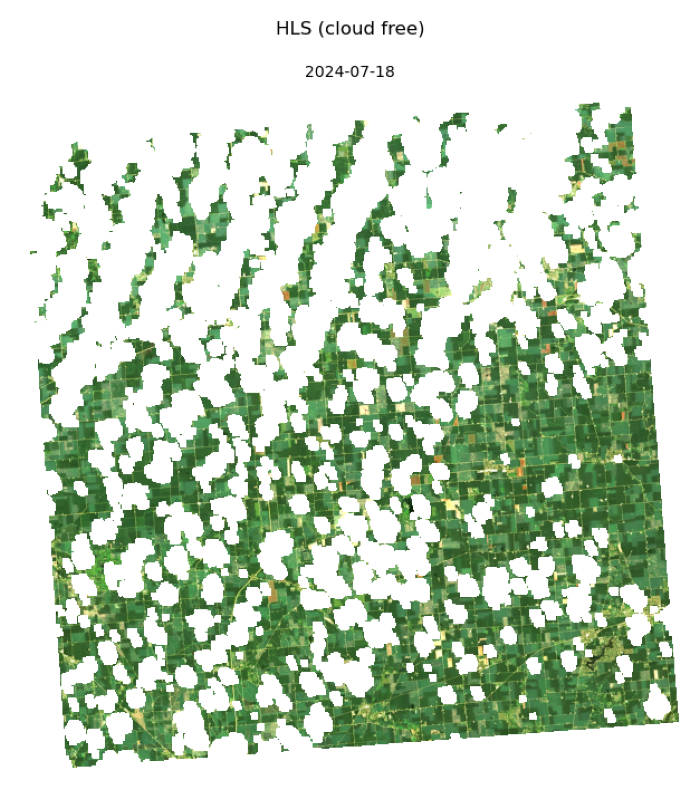

In [61]:
cloud_free_viz = (
    (
        cloud_free_stack.to_dataarray(dim="band")
        .sel(band=["red", "green", "blue"])
        .transpose("y", "x", "band", "time")
    )
    / rgb_max
).clip(0, 1)

render_frame(
    cloud_free_viz,
    time_idx=15,
    title="HLS (cloud free)",
    vmin=0,
    vmax=1000,
    figsize=(10, 10),
)

# render_gif(
#     cloud_free_viz,
#     "HLS (cloud free): April - October 2024",
#     vmin=0,
#     vmax=1000,
# )

### Land cover data
Our crop monitoring analysis would be much simpler if we used an existing dataset to identify pixels in croplands. The Planetary Computer catalog contains a 10-meter resolution annual land cover dataset for 2017-2023. We can create a data cube from this dataset that can be easily combined with our satellite imagery data cube.

In [62]:
# get land cover from Impact Obseratory
landcover_collection_id = "io-lulc-annual-v02"

landcover_search = catalog.search(
    collections=landcover_collection_id,
    bbox=buffer_bbox,
)

landcover_items = landcover_search.item_collection()

landcover_stack = odc.stac.load(
    landcover_items,
    crs=target_crs,
    resolution=30,
    dtype="uint8",
    chunks={},
    x=(bbox_proj[0], bbox_proj[2]),
    y=(bbox_proj[1], bbox_proj[3]),
)["data"].squeeze()

landcover_stack

<xarray.DataArray 'data' (time: 7, y: 1960, x: 1925)> Size: 26MB
dask.array<data, shape=(7, 1960, 1925), dtype=uint8, chunksize=(1, 1960, 1925), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 16kB 2.14e+06 2.14e+06 ... 2.082e+06 2.081e+06
  * x            (x) float64 15kB 5.549e+05 5.549e+05 ... 6.126e+05 6.126e+05
    spatial_ref  int32 4B 5070
  * time         (time) datetime64[ns] 56B 2017-01-01 2018-01-01 ... 2023-01-01
Attributes:
    nodata:   0

Filter the annual datacube down to the 2023 layer so we can use it to classify pixels in the rest of the analysis.

In [63]:
baseline_landcover = landcover_stack.sel(time="2023").drop_vars("time").squeeze()
baseline_landcover

<xarray.DataArray 'data' (y: 1960, x: 1925)> Size: 4MB
dask.array<getitem, shape=(1960, 1925), dtype=uint8, chunksize=(1960, 1925), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 16kB 2.14e+06 2.14e+06 ... 2.082e+06 2.081e+06
  * x            (x) float64 15kB 5.549e+05 5.549e+05 ... 6.126e+05 6.126e+05
    spatial_ref  int32 4B 5070
Attributes:
    nodata:   0

The land cover data are stored as integers; this cell contains the integer/label mapping.

In [64]:
IO_LANDCOVER_CLASSIFICATION_VALUES = {
    0: "no data",
    1: "water",
    2: "trees",
    4: "flooded vegetation",
    5: "crops",
    7: "built area",
    8: "bare ground",
    9: "snow/ice",
    10: "clouds",
    11: "rangeland",
}

landcover_values = np.array(list(IO_LANDCOVER_CLASSIFICATION_VALUES.keys()))
landcover_labels = np.array(list(IO_LANDCOVER_CLASSIFICATION_VALUES.values()))

label_mapping = xr.DataArray(
    landcover_values,
    dims=["landcover_class"],
    coords={"landcover_class": landcover_labels},
)

One clever thing we can do is add the land cover values as coordinates to the imagery data cube! This will make summarization more convenient later on.

In [65]:
cloud_free_with_landcover = cloud_free_stack.assign_coords(
    coords={"landcover_class": (("y", "x"), baseline_landcover.data)}
)

### NDVI

Normalized Difference Vegetation Index (NDVI) is a good proxy for vegetation health, so we will use it for our crop monitoring operations. The next cell creates a 3D NDVI array with invalid pixel observations masked out.

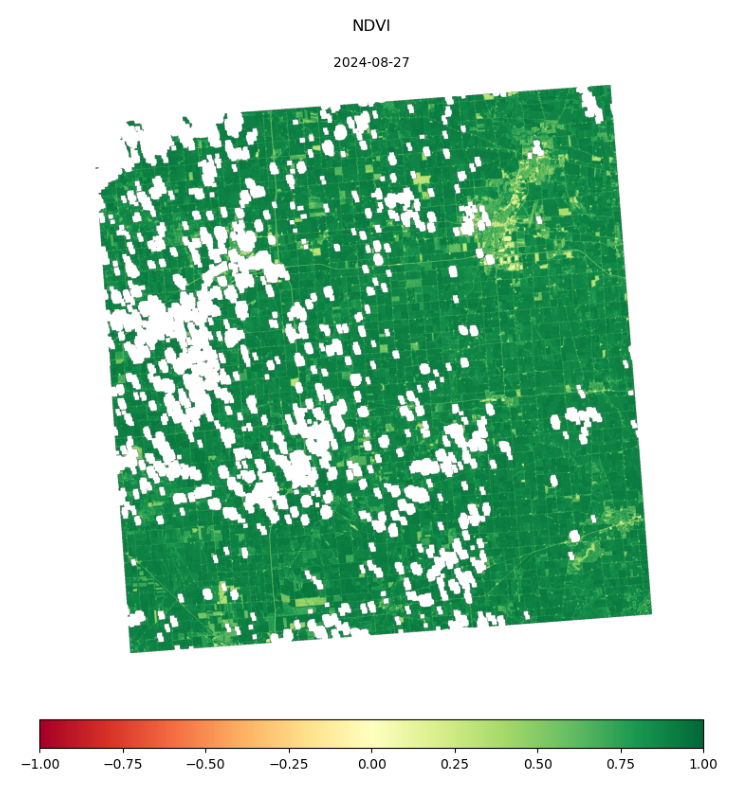

In [69]:
ndvi = (cloud_free_with_landcover["nir08"] - cloud_free_with_landcover["red"]) / (
    cloud_free_with_landcover["nir08"] + cloud_free_with_landcover["red"]
)

ndvi = ndvi.where(np.isfinite(ndvi))

render_frame(
    (ndvi.transpose("y", "x", "time")),
    time_idx=24,
    title="NDVI",
    vmin=-1,
    vmax=1,
    cmap="RdYlGn",
    figsize=(10, 10),
)

# render_gif(
#     (ndvi.transpose("y", "x", "time")),
#     "NDVI: April - October 2024",
#     vmin=-1,
#     vmax=1,
#     cmap="RdYlGn",
# )

To identify anomalies, we will compare individual pixel image-over-image NDVI changes to the average image-over-image change for the entire crop land cover class. The following cell computes a smoothed NDVI trend for the whole time series of our imagery stack.

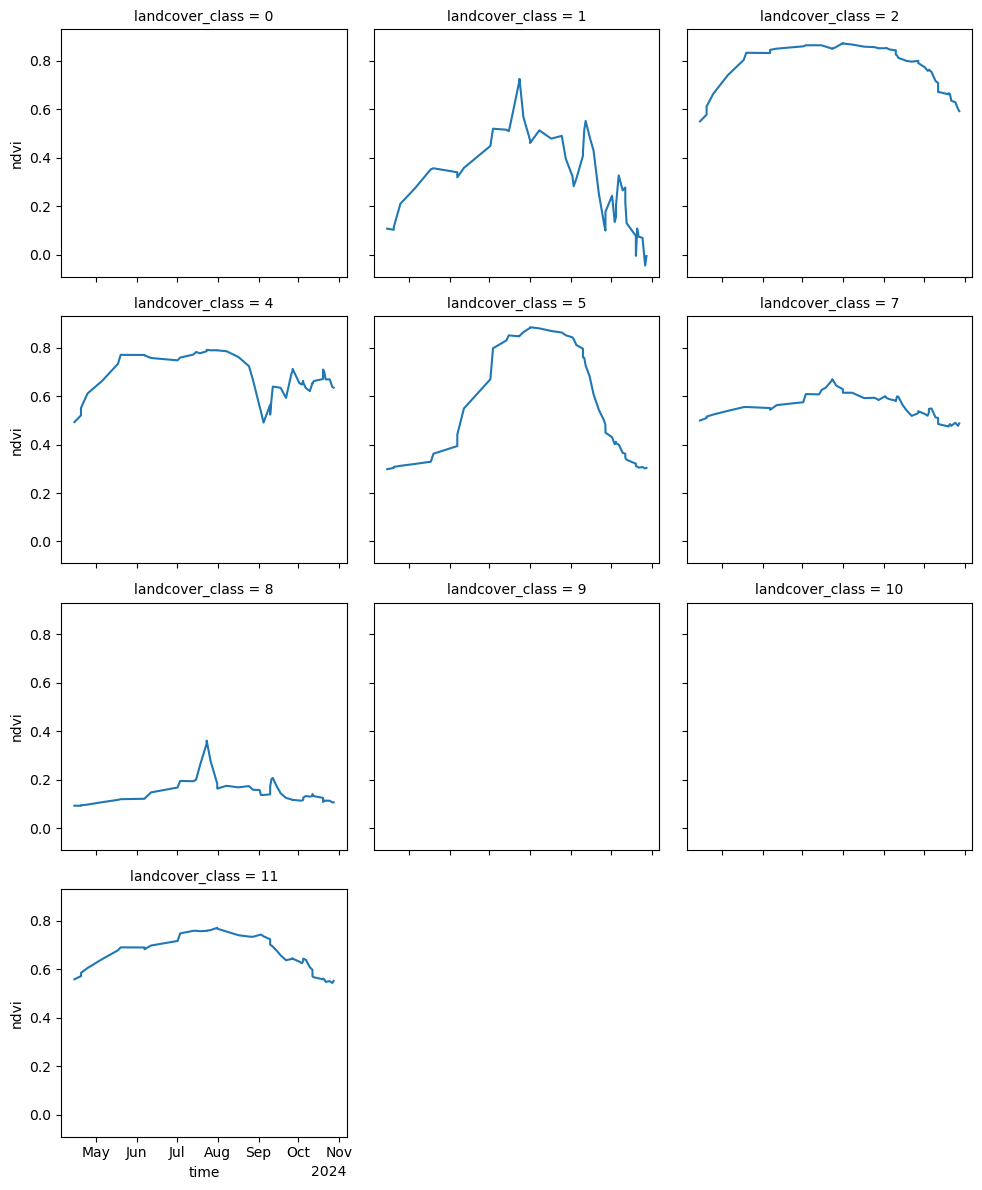

In [70]:
avg_ndvi_trend = (
    ndvi.groupby(landcover_class=xr.groupers.UniqueGrouper(labels=landcover_values))
    .mean(dim=["x", "y"], skipna=True)
    .chunk({"time": -1})
    .interpolate_na(dim="time", method="linear", limit=3)
    .rolling(time=3, center=True)
    .mean()
    .assign_coords(coords={"landcover_name": ("landcover_class", landcover_labels)})
    .rename("ndvi")
    .drop_vars("spatial_ref")
    .compute()
)

xr.plot.line(
    avg_ndvi_trend,
    x="time",
    col="landcover_class",
    col_wrap=3,
)

We will evaluate the image-over-image change to identify pixels where the change is highly negative when most other crop pixels show an increase in NDVI.

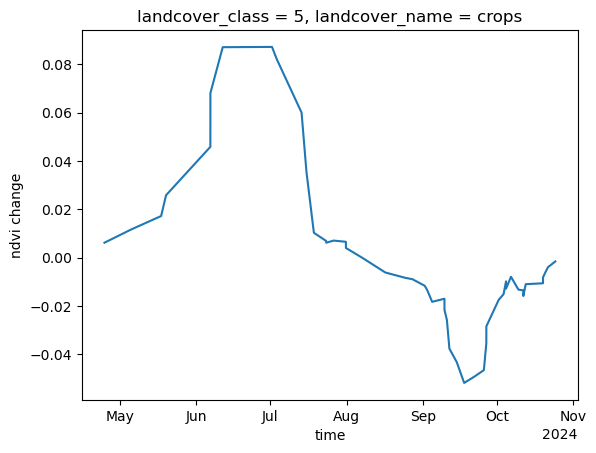

In [71]:
avg_ndvi_delta = (
    avg_ndvi_trend.diff(dim="time", n=1)
    .rolling(time=5, center=True)
    .mean()
    .rename("ndvi change")
)

xr.plot.line(
    avg_ndvi_delta.sel(landcover_class=5),
    x="time",
)

### Anomaly detection

The difference between a pixel's image-over-image change and the expected value (average) for the entire cropland cover class at a given point in time represents the "deviation from expectation.” Pixels with highly negative values may have experienced an unexpected decline in vegetation health.

In [72]:
pixel_baseline_ndvi_delta = avg_ndvi_delta.sel(landcover_class=baseline_landcover)

pixel_ndvi_delta = ndvi.diff(dim="time", n=1)

deviation_over_time = pixel_ndvi_delta - pixel_baseline_ndvi_delta

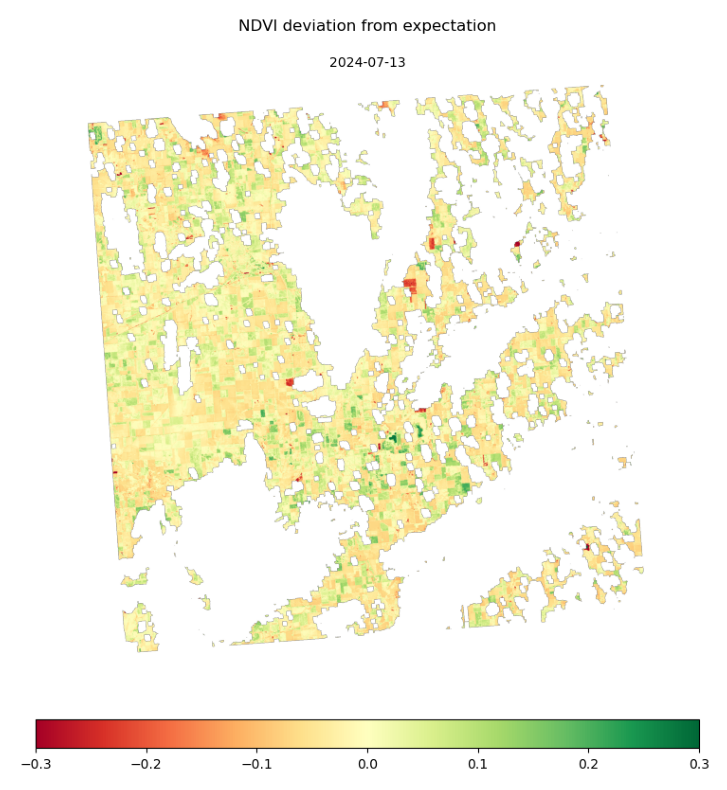

In [75]:
render_frame(
    (deviation_over_time.transpose("y", "x", "time")),
    time_idx=12,
    title="NDVI deviation from expectation",
    vmin=-0.3,
    vmax=0.3,
    cmap="RdYlGn",
    figsize=(10, 10),
)

# render_gif(
#     (deviation_over_time.transpose("y", "x", "time")),
#     "NDVI deviation from expectation: April - October 2024",
#     vmin=-0.3,
#     vmax=0.3,
#     cmap="RdYlGn",
# )

We are trying to find areas that showed **decreased** NDVI when similar pixels **increased**.

Now define a threshold for classifying a pixel as having an anomalous decrease in NDVI. Pixels where the difference between its change in NDVI and the expected value is at least as negative as the threshold will be classified as anomalies.

In [76]:
threshold = -0.2

crop_anomalies = (
    (pixel_ndvi_delta < 0)
    & (deviation_over_time < threshold)
    & (pixel_baseline_ndvi_delta > 0)
    & (baseline_landcover == 5).compute()
)

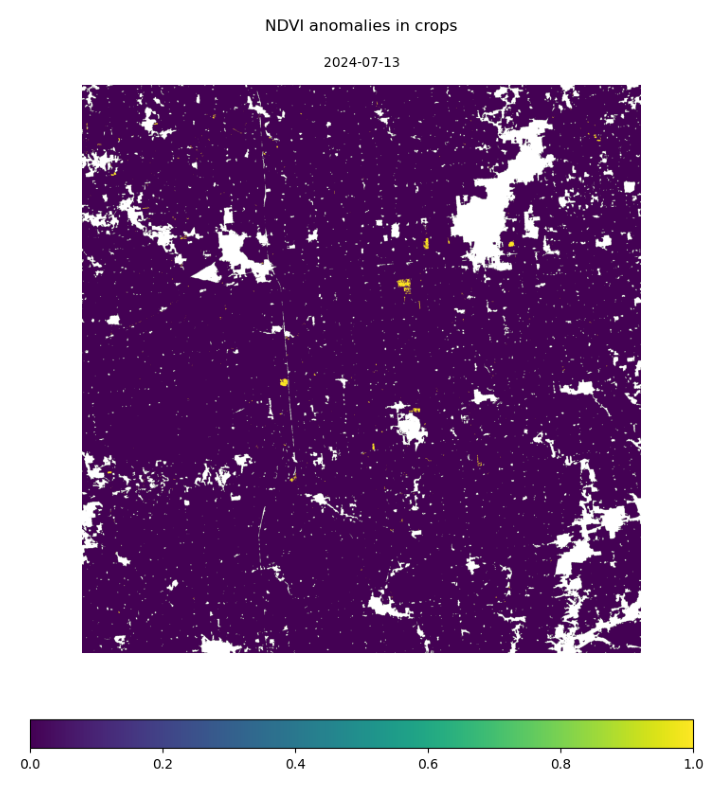

In [78]:
anomaly_viz = (
    (1 * crop_anomalies).where(baseline_landcover == 5).transpose("y", "x", "time")
)

render_frame(
    anomaly_viz,
    time_idx=12,
    title="NDVI anomalies in crops",
    vmin=0,
    vmax=1,
    cmap="viridis",
    figsize=(10, 10),
)

# render_gif(
#     anomaly_viz,
#     "NDVI anomalies in crops: April - October 2024",
#     vmin=0,
#     vmax=1,
#     cmap="viridis",
# )

To capture the actual date of the first anomalous event in the time series, use the `idxmax` method. This will calculate the time coordinate values where each pixel had a marked anomaly (`True` in the `crop_anomalies` array).

In [79]:
anomaly_time = crop_anomalies.idxmax(dim="time")

For plotting, we want to express the anomaly date as a numeric value like "number of days from the beginning of the time series".

In [80]:
start_time = crop_anomalies.time.min()

# get difference between anomaly datetime and first image time
anomaly_delta = anomaly_time - start_time

# convert to days
n_days = (anomaly_delta / np.timedelta64(1, "D")).where(crop_anomalies.any(dim="time"))

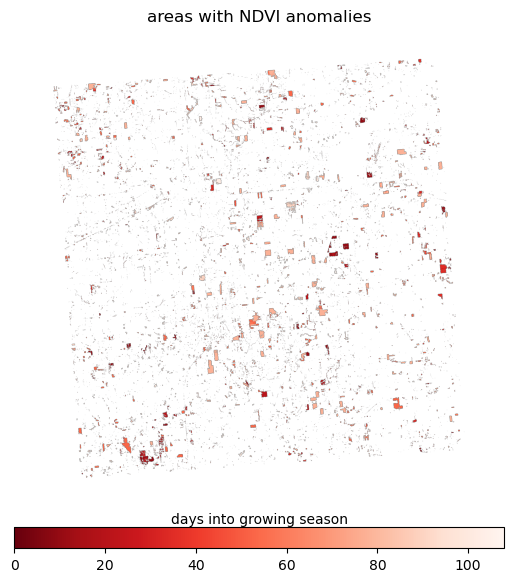

In [81]:
fig, ax = plt.subplots(figsize=(7, 7))
im = ax.imshow(
    n_days.drop_vars("spatial_ref"), vmin=0, vmax=n_days.max(), cmap="Reds_r"
)
ax.axis("off")

plt.subplots_adjust(left=0.1, right=0.9, top=0.85, bottom=0.25)

fig.suptitle("areas with NDVI anomalies", fontsize=12, y=0.92)

cbar_ax = fig.add_axes([0.15, 0.15, 0.7, 0.03])
cbar = plt.colorbar(im, cax=cbar_ax, orientation="horizontal")
cbar.set_label("days into growing season", fontsize=10, labelpad=3)
cbar.ax.xaxis.set_label_position("top")
plt.savefig("images/ndvi-anomalies.png", bbox_inches="tight", pad_inches=0.1)

Plot it in an interactive map! Brighter red values indicate an earlier anomalous event.

Now convert the anomalous pixels into polygons that we can view alongside our original field boundaries

In [ ]:
# create polygons from the anomalous regions that are at least 10 hectares (25 acres)
features = []
min_area_m2 = 10_000 * 10  # 10 hectares / 25 acres

for feat in shapes(
    n_days.astype("float32").data,
    transform=n_days.rio.transform(),
):
    geom = shape(feat[0])
    if geom.area >= min_area_m2 and not np.isnan(feat[1]):
        features.append((geom, feat[1]))

# load features into a geodataframe
anomaly_gdf = (
    gpd.GeoDataFrame(
        {"n_days": [feat[1] for feat in features]},
        geometry=[feat[0] for feat in features],
        crs=target_crs,
    )
    .explode()
    .reset_index()
    .to_crs(4326)
)

# make a map
m = folium.Map([lat, lon], zoom_start=12)

colors = cm.linear.OrRd_09.colors
colors.reverse()

colormap = cm.LinearColormap(list(colors)).scale(
    anomaly_gdf.n_days.min(), anomaly_gdf.n_days.max()
)

folium.GeoJson(
    anomaly_gdf.to_geo_dict(),
    style_function=lambda feature: {
        "fillColor": colormap(feature["properties"]["n_days"]),
        "weight": 1,
        "color": "black",
        "fillOpacity": 0.9,
    },
).add_to(m)

colormap.caption = "number of days into growing season"
colormap.add_to(m)

folium.features.GeoJson(
    data=field_gdf,
    name="field boundaries",
).add_to(m)

folium.LayerControl().add_to(m)

m

### Export for tabular analysis
The anomalous areas can be conveniently exported to geoparquet with the `GeoDataFrame.to_parquet` method:

In [67]:
anomaly_gdf.to_parquet(
    "/tmp/anomalies.parquet", compression="zstd", write_covering_bbox=True
)

### ✅ Next Steps  
This notebook explored time-series vegetation monitoring using HLS (Harmonized Landsat and Sentinel-2) imagery and NDVI to track changes in vegetation health over time for a defined location.

To continue learning about site monitoring workflows, check out the next notebook:

👉 (climate-risk.ipynb)[tutorial/climate-risk.ipynb]  
This advanced notebook focuses on extreme weather conditions that could lead to wildfire events. It explores using additional indices, temporal filtering, and geospatial joins to infrastructure data.